In [21]:
# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14,6)

In [23]:
# Load & Check Data

In [25]:
df = pd.read_csv('bitcoin_dataset.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100
...,...,...,...,...,...,...
2026-06-01,73580.210938,73969.570312,70599.507812,71319.773438,71319.773438,43378836121
2026-06-02,71321.031250,71334.953125,66127.265625,66703.656250,66703.656250,54990073882
2026-06-03,66694.007812,67402.929688,64009.675781,64014.367188,64014.367188,47411556213


In [26]:
print(df.shape)
df.head

(4280, 6)


<bound method NDFrame.head of                     Open          High           Low         Close  \
Date                                                                 
2014-09-17    465.864014    468.174011    452.421997    457.334015   
2014-09-18    456.859985    456.859985    413.104004    424.440002   
2014-09-19    424.102997    427.834991    384.532013    394.795990   
2014-09-20    394.673004    423.295990    389.882996    408.903992   
2014-09-21    408.084991    412.425995    393.181000    398.821014   
...                  ...           ...           ...           ...   
2026-06-01  73580.210938  73969.570312  70599.507812  71319.773438   
2026-06-02  71321.031250  71334.953125  66127.265625  66703.656250   
2026-06-03  66694.007812  67402.929688  64009.675781  64014.367188   
2026-06-04  64020.070312  64664.445312  61335.750000  63801.574219   
2026-06-05  63807.691406  63901.515625  59108.917969  60922.667969   

               Adj Close       Volume  
Date               

In [24]:
# Data Quality Check

In [33]:
# Check missing values
print(df.isnull().sum())

# Check for data gaps
date_diffs = df.index.to_series().diff().dt.days
print("\nGap distribution:")
print(date_diffs.value_counts().sort_index())

# Basic stats
df.describe()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Gap distribution:
Date
1.0    4279
Name: count, dtype: int64


,Open,High,Low,Close,Adj Close,Volume
count,4280.000000,4280.000000,4280.000000,4280.000000,4280.000000,4.280000e+03
mean,28623.330630,29188.324150,28019.749124,28636.451670,28636.451670,2.230348e+10
std,32442.204251,32986.012544,31852.792883,32442.454923,32442.454923,2.294359e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,3452.187439,3504.092224,3391.943420,3458.813721,3458.813721,1.676575e+09
50%,11536.727539,11850.328613,11288.414062,11564.331543,11564.331543,1.802679e+10
75%,46401.472656,47432.591797,45184.174805,46446.924805,46446.924805,3.446429e+10
max,124752.140625,126198.070312,123196.046875,124752.531250,124752.531250,3.509679e+11


In [34]:
# Price history plot

Text(0, 0.5, 'Price(USD, lod scale)')

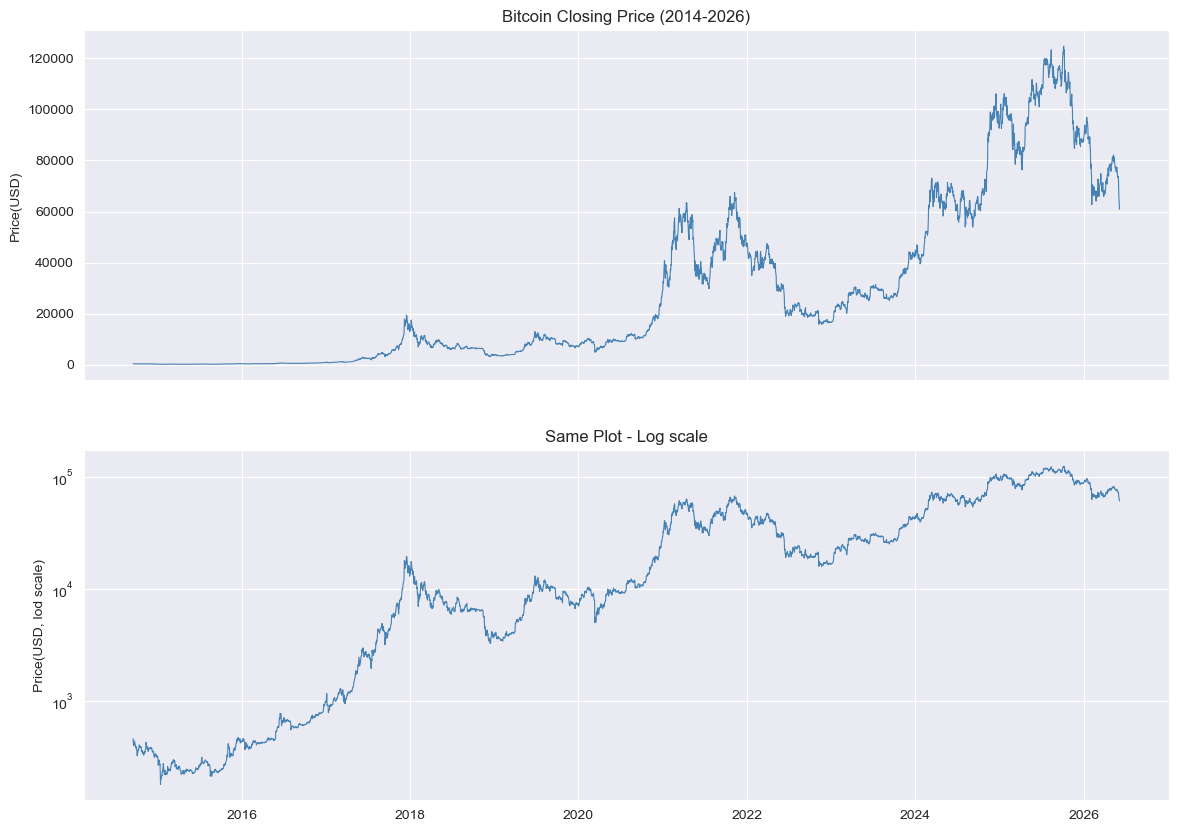

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=0.8)
axes[0].set_title('Bitcoin Closing Price (2014-2026)')
axes[0].set_ylabel('Price(USD)')

axes[1].plot(df.index, df['Close'],color='steelblue', linewidth=0.8)
axes[1].set_yscale('log')
axes[1].set_title('Same Plot - Log scale')
axes[1].set_ylabel('Price(USD, lod scale)')

In [ ]:
# Daily returns

In [36]:
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['simple_return'] = df['Close'].pct_change()

df[['log_return', 'simple_return']].describe()

,log_return,simple_return
count,4279.000000,4279.000000
mean,0.001143,0.001758
std,0.035148,0.034916
min,-0.464730,-0.371695
25%,-0.012698,-0.012617
50%,0.001072,0.001073
75%,0.015759,0.015884
max,0.225119,0.252472


In [ ]:
# Plot returns

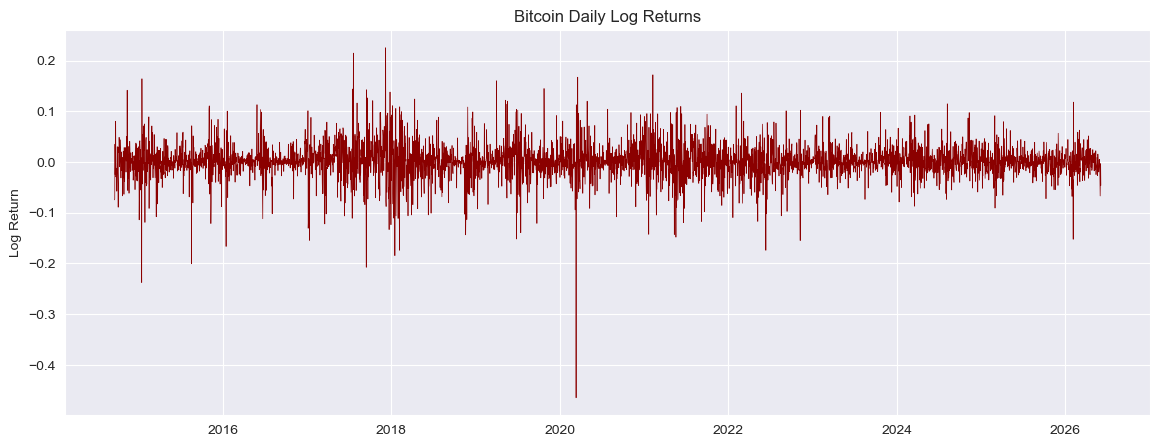

In [37]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['log_return'], color='darkred', linewidth=0.5)
ax.set_title('Bitcoin Daily Log Returns')
ax.set_ylabel('Log Return')
plt.show()

In [39]:
# Rolling Volatility

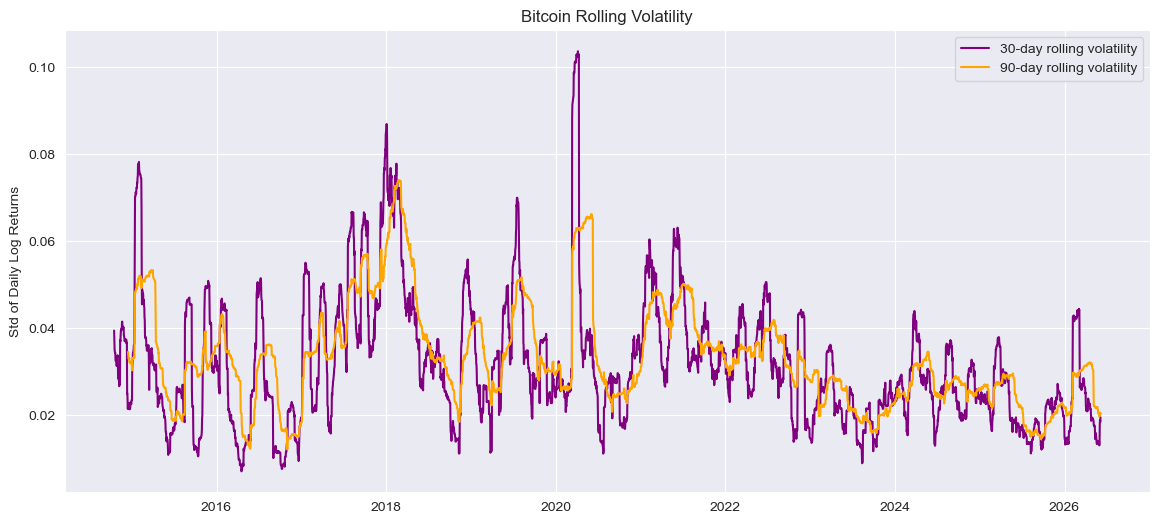

In [40]:
df['vol_7d'] = df['log_return'].rolling(7).std()
df['vol_30d'] = df['log_return'].rolling(30).std()
df['vol_90d'] = df['log_return'].rolling(90).std()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['vol_30d'], label='30-day rolling volatility', color='purple')
ax.plot(df.index, df['vol_90d'], label='90-day rolling volatility', color='orange', linewidth=1.5)
ax.set_title('Bitcoin Rolling Volatility')
ax.set_ylabel('Std of Daily Log Returns')
ax.legend()
plt.show()

In [38]:
# ADF Stationarity Test (this one needs a new import)

In [41]:
from statsmodels.tsa.stattools import adfuller

result_price = adfuller(df['Close'].dropna())
result_returns = adfuller(df['log_return'].dropna())

print(f"Price ADF p-value: {result_price[1]:.4f}")
print(f"Returns ADF p-value: {result_returns[1]:.4f}")

Price ADF p-value: 0.5799
Returns ADF p-value: 0.0000
